<a href="https://colab.research.google.com/github/gautamkushwaha/ML-and-Deep-Learning-Projects/blob/main/AutoEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# Simple Autoencoder
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [2]:
# -------------------------
# Dummy data (replace later)
# -------------------------
# Shape: (samples, features)
X = np.random.randn(1000, 128)
X = torch.tensor(X, dtype=torch.float32)


In [3]:
# -------------------------
# Autoencoder model
# -------------------------
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16)   # latent space
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = AutoEncoder()

In [4]:
# -------------------------
# Training setup
# -------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [5]:
# -------------------------
# Training loop
# -------------------------
epochs = 50
for epoch in range(epochs):
    optimizer.zero_grad()

    X_hat = model(X)
    loss = criterion(X_hat, X)

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


Epoch 0, Loss: 1.007898
Epoch 10, Loss: 1.000633
Epoch 20, Loss: 0.994652
Epoch 30, Loss: 0.985683
Epoch 40, Loss: 0.971263


In [6]:
# -------------------------
# Get latent representation
# -------------------------
latent = model.encoder(X)
print("Latent shape:", latent.shape)

Latent shape: torch.Size([1000, 16])


In [7]:
x = torch.tensor([2.0], requires_grad=True)
y = x * x + 3
y.backward()
print(x.grad)


tensor([4.])


In [8]:
import torch

x = torch.randn(1, requires_grad=True)
y = x * 2
z = y.mean()

print(x.grad_fn)
print(y.grad_fn)
print(z.grad_fn)


None


In [10]:
z_detached = z.detach()


In [12]:
x = torch.tensor(2.0, requires_grad=True)
y = x * 3
# z = y.detach()  <-- This was breaking the gradient chain
z = y
loss = z * 2

loss.backward()
print(f"Gradient of x: {x.grad}")

Gradient of x: 6.0


In [9]:
X_hat = model(X)
print(X_hat.grad_fn)


**Simplest Image Autoencoder (PyTorch)**

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


2. Load MNIST (images only)
- Each image: 1 × 28 × 28

- Pixel values in [0, 1]

In [14]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 58.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.17MB/s]


In [15]:
class SimpleAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder: 784 → 32
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        # Decoder: 32 → 784
        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()  # output pixels in [0,1]
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)   # flatten image
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


In [16]:
model = SimpleAutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [17]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    for images, _ in train_loader:
        optimizer.zero_grad()

        recon = model(images)
        loss = criterion(recon, images.view(images.size(0), -1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1, Loss: 0.0471
Epoch 2, Loss: 0.0198
Epoch 3, Loss: 0.0147
Epoch 4, Loss: 0.0124
Epoch 5, Loss: 0.0111


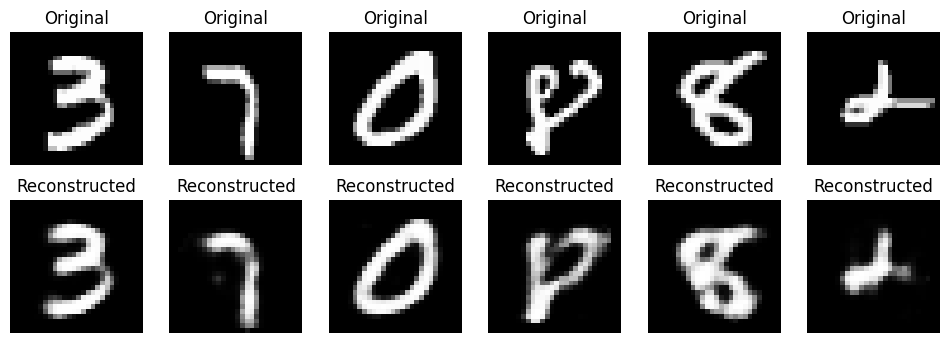

In [18]:
images, _ = next(iter(train_loader))

with torch.no_grad():
    recon = model(images)

# show original and reconstructed
fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(recon[i].view(28, 28), cmap='gray')
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis('off')

plt.show()


Top row → original digits

Bottom row → reconstructed (slightly blurry)

That blur = compression loss.

28×28 image (784)

        ↓
Encoder (compression)

        ↓
Latent vector (32)

        ↓
Decoder (reconstruction)

        ↓
28×28 image (784)


An image autoencoder learns a compressed representation that preserves only what is necessary to reconstruct the image.

🚀 What you can do next (incrementally)

- Change latent size: 32 → 8 → 2

- Visualize latent space (2D)

- Add noise → denoising autoencoder

- Replace Linear → Conv layers

- Convert to Variational Autoencoder

1. Computatioj Graph for the simple image Autoencoder:
784 → 128 → 32 → 128 → 784


Image (28×28) →
Flatten (view) →
Linear(784 → 128)→ReLU →
Linear(128 → LATENT)→
Latent vector z →
Linear(LATENT → 128)→
ReLU→Linear(128 → 784)→
Sigmoid→Reconstructed image (x̂)→
MSELoss(x̂, x)


**🔹 Backward pass (automatic)**

Loss
↑
Gradients flow backward
 ↑
Decoder weights
 ↑
Latent z
 ↑
Encoder weights


In [ ]:
# latent space visualization


Train an autoencoder with latent dimension = 2

Encode MNIST images

Plot each image as a point in 2D

Color by digit label → visualize structure

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [20]:
transform = transforms.ToTensor()

dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=256, shuffle=True)


In [21]:
class AE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 2)   # 🔥 latent = 2
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


In [22]:
model = AE()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 5
for epoch in range(epochs):
    for images, _ in loader:
        optimizer.zero_grad()
        recon = model(images)
        loss = criterion(recon, images.view(images.size(0), -1))
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} done")


Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done


In [23]:
latents = []
labels = []

with torch.no_grad():
    for images, y in loader:
        images = images.view(images.size(0), -1)
        z = model.encoder(images)
        latents.append(z)
        labels.append(y)

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()


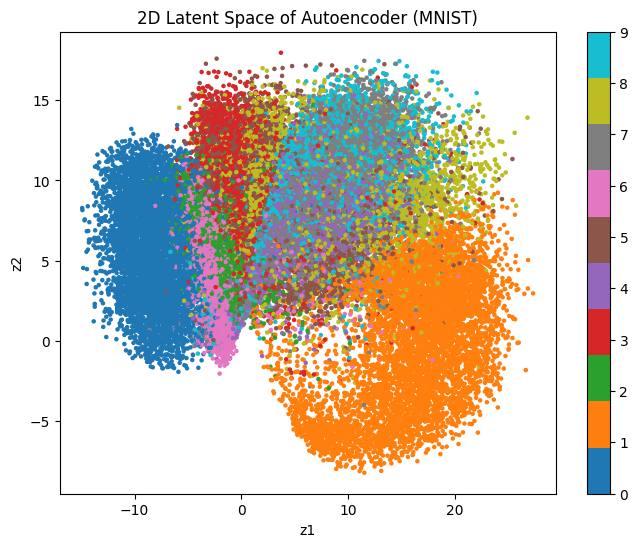

In [24]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    latents[:, 0],
    latents[:, 1],
    c=labels,
    cmap="tab10",
    s=5
)
plt.colorbar(scatter, ticks=range(10))
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("2D Latent Space of Autoencoder (MNIST)")
plt.show()


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# grid size
n = 20

# range of latent values (adjust if needed)
latent_range = 3

z1 = np.linspace(-latent_range, latent_range, n)
z2 = np.linspace(-latent_range, latent_range, n)

grid = np.array([[x, y] for y in z2 for x in z1])
grid = torch.tensor(grid, dtype=torch.float32)


In [26]:
with torch.no_grad():
    decoded = model.decoder(grid)


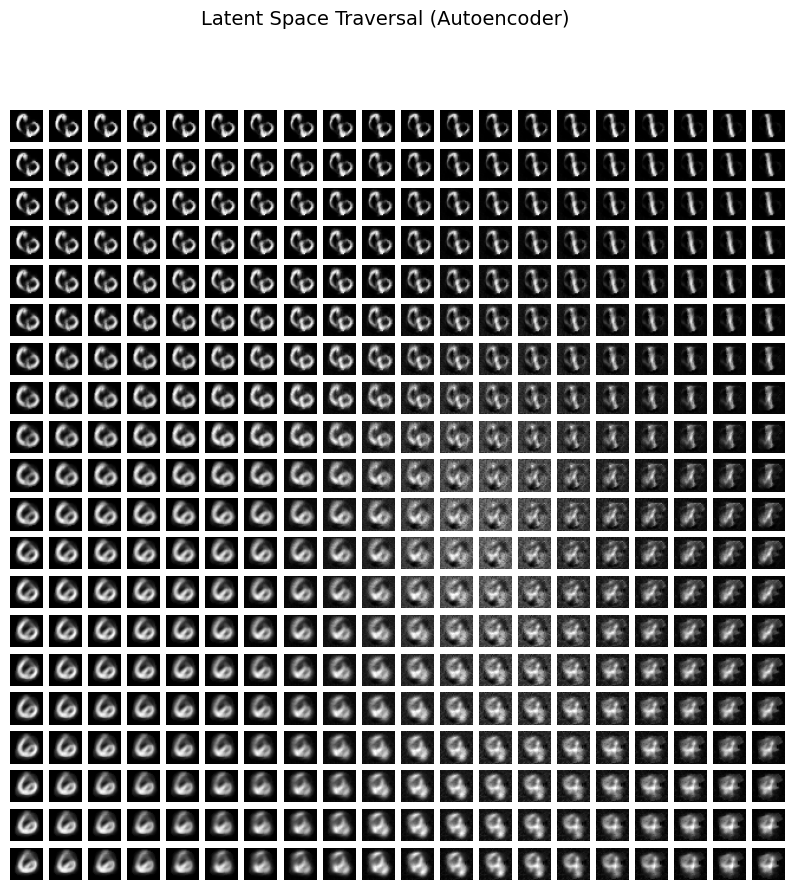

In [27]:
fig, axes = plt.subplots(n, n, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(decoded[i].view(28, 28), cmap='gray')
    ax.axis('off')

plt.suptitle("Latent Space Traversal (Autoencoder)", fontsize=14)
plt.show()
